In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/diabetes.csv')

# 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df2=df.drop('Outcome',axis=1) # Outcome 열을 제거한 데이터를 df2에 저장
df.head()                     # df의 상위 5개 행을 출력


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
y=df2['BMI']       # BMI 열을 타깃값(y)으로 저장
y.value_counts()    # BMI 값들의 개수 확인
y


,BMI
0,33.6
1,26.6
2,23.3
3,28.1
4,43.1
...,...
763,32.9
764,36.8
765,26.2
766,30.1


In [ ]:
X=df2.drop('BMI',axis=1)    # BMI 열을 제외한 나머지 열을 입력값(X)으로 저장
X.head()                    # X의 상위 5개 행을 출력

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,0.627,50
1,1,85,66,29,0,0.351,31
2,8,183,64,0,0,0.672,32
3,1,89,66,23,94,0.167,21
4,0,137,40,35,168,2.288,33


In [ ]:
scaler = StandardScaler() # 각 특성(열)의 평균을 0, 표준편차를 1로 맞추기 위한 객체 생성
X = scaler.fit_transform(X) # 그 값을 이용해 데이터를 표준화(transform)

In [ ]:
# y의 범주형 값을 원-핫 인코딩(One-Hot Encoding)으로 변환한 뒤
# 넘파이 배열 형태로 저장
Y = pd.get_dummies(y).values

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((614, 7), (614, 248), (154, 7), (154, 248))

In [ ]:
# 모델 정의

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD, Adam

# Sequential 모델 생성
# 층을 순서대로 쌓는 가장 기본적인 신경망 모델
model = Sequential()

# 입력층 + 첫 번째 은닉층
# 뉴런 8개, 입력 데이터의 특성 개수는 X.shape[1]
# 활성화 함수는 ReLU 사용
model.add(Dense(8, input_shape=(X.shape[1],), activation='relu'))

# 두 번째 은닉층
# 뉴런 30개, 활성화 함수는 ReLU
model.add(Dense(30, activation='relu'))

# 세 번째 은닉층
# 뉴런 30개, 활성화 함수는 ReLU
model.add(Dense(30, activation='relu'))

# 출력층
# 뉴런 1개이므로 회귀 문제에 적합한 형태
model.add(Dense(1))

# 모델 학습 설정
# optimizer: 가중치 갱신 방법으로 rmsprop 사용
# loss: 손실 함수로 평균제곱오차(mse) 사용
# metrics: 학습 과정에서 mse를 함께 출력
model.compile(optimizer='rmsprop', loss='mse', metrics=['mse'])

# 모델 구조 요약 출력
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295 (5.06 KB)

 Trainable params: 1,295 (5.06 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
N_EPOCHS = 10

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0165 - mse: 0.0165 - val_loss: 0.0072 - val_mse: 0.0072
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0063 - mse: 0.0063 - val_loss: 0.0056 - val_mse: 0.0056
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0053 - mse: 0.0053 - val_loss: 0.0055 - val_mse: 0.0055
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - mse: 0.0049 - val_loss: 0.0047 - val_mse: 0.0047
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - mse: 0.0047 - val_loss: 0.0049 - val_mse: 0.0049
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - mse: 0.0045 - val_loss: 0.0045 - val_mse: 0.0045
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0044 - mse: 0.0044 - val_loss: 0.0045 - val_mse: 0.0045
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - mse: 0.0043 - val_loss: 0.0044 - val_mse: 0.0044
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0043 - mse:

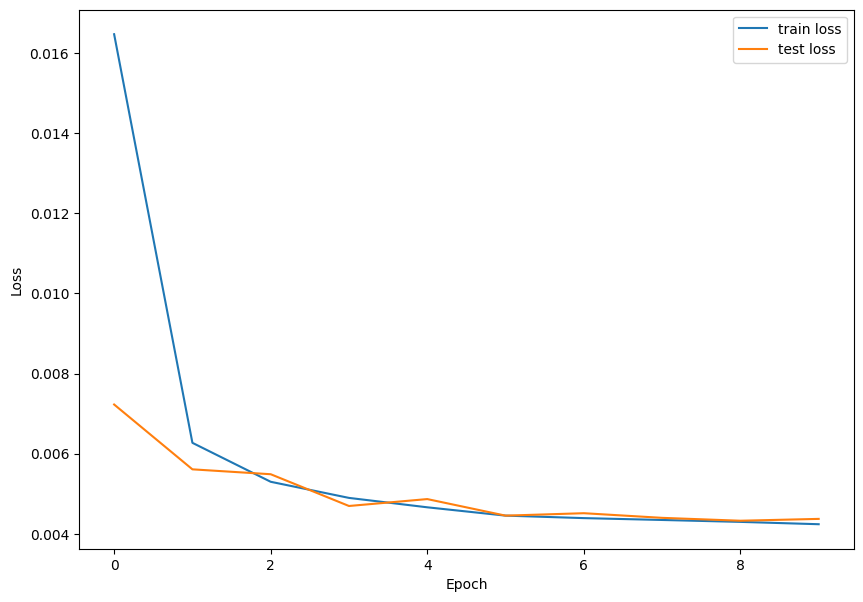

In [ ]:
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0044 - mse: 0.0044 


[0.004373134579509497, 0.004373134579509497]